In [1]:
!pip install pandas numpy matplotlib scikit-learn shap notebook

  Using cached numpy-2.4.6-cp312-cp312-macosx_14_0_x86_64.whl.metadata (6.6 kB)
INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 2.8 MB/s  0:00:02 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: contourpy━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/4 [numpy]
    Found existing installation: contourpy 1.2.0━━━━━━━━━━━━━━ 1/4 [numpy]
    Uninstalling contourpy-1.2.0:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/4 [numpy]
      Successfully uninstalled contourpy-1.2.0━━━━━━━━━━━━━━━━ 1/4 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [shap]3/4 [shap]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts

In [3]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
 
import shap


In [4]:
# Step 2: Create the Sample Dataset
data = {
    "Age": [35,42,38,29,31,45,28,33,40,36,30,50,27,39,44,41,32,47,36,34],
    "Income": [75000,82000,68000,65000,62000,95000,54000,72000,76000,81000,60000,100000,52000,78000,73000,85000,61000,93000,70000,76000],
    "CreditScore": [720,740,690,700,680,780,650,710,700,730,670,790,640,720,700,750,675,770,690,725],
    "LoanAmount": [250000,300000,200000,180000,175000,350000,150000,220000,240000,280000,160000,400000,140000,260000,230000,310000,170000,360000,210000,245000],
    "Approved": [1,1,0,1,0,1,0,1,1,1,0,1,0,1,1,1,0,1,0,1]
}
 
df = pd.DataFrame(data)
df.head()


,Age,Income,CreditScore,LoanAmount,Approved
0,35,75000,720,250000,1
1,42,82000,740,300000,1
2,38,68000,690,200000,0
3,29,65000,700,180000,1
4,31,62000,680,175000,0


In [5]:
# Step 3: Define Features and Target
X = df[["Age", "Income", "CreditScore", "LoanAmount"]]
y = df["Approved"]


In [6]:
# Step 4: Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)



In [7]:
# Step 5: Train the Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
 
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [8]:
# Step 6: Evaluate Model Accuracy
y_pred = model.predict(X_test)
 
accuracy = accuracy_score(y_test, y_pred)
 
print(f"Model Accuracy: {accuracy:.2f}")
 


Model Accuracy: 1.00


In [9]:
# Step 7: Review Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)
 
feature_importance


,Feature,Importance
2,CreditScore,0.431043
1,Income,0.303720
3,LoanAmount,0.234990
0,Age,0.030247


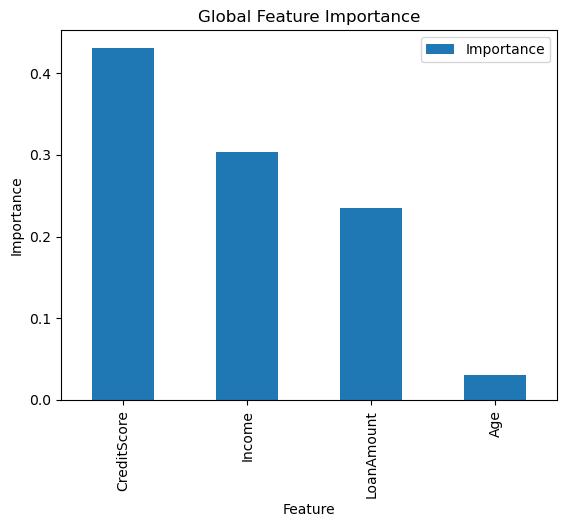

In [10]:
# Step 8: Visualize Feature Importance
feature_importance.plot(
    kind="bar",
    x="Feature",
    y="Importance",
    title="Global Feature Importance"
)
 
plt.ylabel("Importance")
plt.show() 


In [11]:
# Step 9: Generate a Prediction for One Applicant
sample_applicant = X_test.iloc[[0]]
 
sample_applicant
 


,Age,Income,CreditScore,LoanAmount
0,35,75000,720,250000


In [12]:
prediction = model.predict(sample_applicant)[0]
probability = model.predict_proba(sample_applicant)[0]
 
print(f"Prediction: {'Approved' if prediction == 1 else 'Denied'}")
print(f"Approval Probability: {probability[1]:.2f}")
print(f"Denial Probability: {probability[0]:.2f}")


Prediction: Approved
Approval Probability: 1.00
Denial Probability: 0.00


In [13]:
# Step 10: Explain the Prediction Using SHAP
explainer = shap.TreeExplainer(model)
 
shap_values = explainer.shap_values(X_test)


In [15]:
# For some SHAP versions, classification output may be returned as a list. Use:
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values


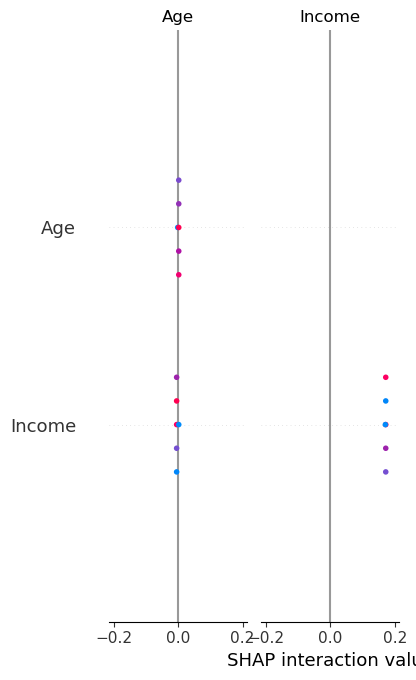

In [16]:
# Step 11: SHAP Summary Plot
shap.summary_plot(
    shap_values_to_plot,
    X_test
)


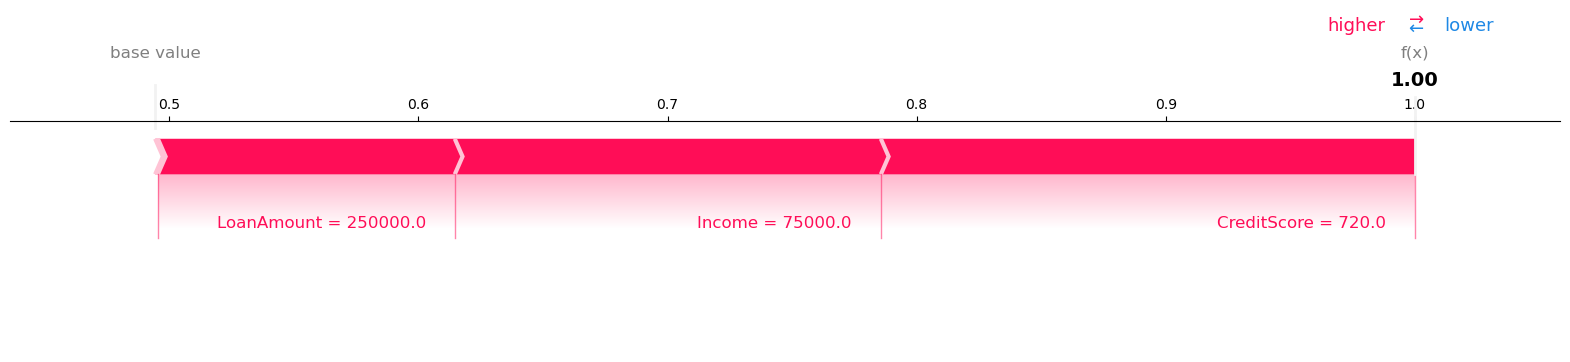

In [23]:
# Step 12: Explain One Applicant
sample_index = 0

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1]
base_value = float(base_value)

single_shap_values = shap_values_to_plot[sample_index, :, 1]
single_features = X_test.iloc[[sample_index]]   # double brackets keep one row

shap.plots.force(
    base_value,
    single_shap_values,
    single_features,
    matplotlib=True
)

In [25]:
# Step 13: Create a Simple Explanation Table
shap_row = shap_values_to_plot[sample_index]

# If SHAP has multiple output classes, select class 1
if np.array(shap_row).ndim > 1:
    shap_row = shap_row[:, 1]

shap_row = np.array(shap_row).flatten()

explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Applicant Value": X_test.iloc[sample_index].values,
    "SHAP Contribution": shap_row
}).sort_values(
    by="SHAP Contribution",
    ascending=False
)

explanation

,Feature,Applicant Value,SHAP Contribution
2,CreditScore,720,0.214373
1,Income,75000,0.171050
3,LoanAmount,250000,0.119189
0,Age,35,0.001102


In [26]:
# Step 14: Save Explanation Report
top_features = explanation.head(3)
 
report = f"""
# Explainable AI Report
 
## Model
Random Forest Loan Approval Model
 
## Model Accuracy
{accuracy:.2f}
 
## Global Explanation
The model's most important features are:
 
{feature_importance.to_string(index=False)}
 
## Local Explanation
A sample applicant received the following prediction:
 
Prediction: {'Approved' if prediction == 1 else 'Denied'}
 
Approval Probability: {probability[1]:.2f}
 
The top factors influencing this prediction were:
 
{top_features.to_string(index=False)}
 
## Responsible AI Interpretation
This explanation helps reviewers understand which applicant characteristics influenced the model's decision. 
Explainability supports transparency, auditability, human review, and regulatory compliance.
 
## Recommendations
Business and compliance teams should review whether the most influential features are appropriate, legally permissible, and aligned with organizational lending policies.
"""
 
with open("explainable_ai_report.md", "w") as file:
    file.write(report)
 
print("Explainable AI report saved as explainable_ai_report.md")


Explainable AI report saved as explainable_ai_report.md
